<h1 align="center">Estudio Estadístico: Distribución de Poisson en Flujo Vehicular</h1>

**Análisis de Turismo (Semana Santa).** Al concluir el periodo vacacional, se registró que en la caseta de la autopista México-Cuernavaca ingresaba un volumen promedio de 75 automóviles por cada minuto transcurrido. Tomando como base este indicador de flujo, se solicita calcular la probabilidad de las siguientes variables operacionales en un minuto seleccionado al azar:

a) Ingreso exacto de 80 vehículos.

b) Ingreso exacto de 50 vehículos.

c) Ingreso acumulado de 800 vehículos en un lapso continuo de 15 minutos.

---

### Modelación Matemática del Fenómeno
El problema plantea la cuantificación de eventos discretos (arribo de autos) en un intervalo de tiempo continuo (un minuto) a partir de una tasa media conocida ($\lambda = 75$). Por lo tanto, el comportamiento de la variable se modela mediante una **Distribución de Poisson**.

Definición de la variable aleatoria:
$X =$ Cantidad de automóviles que cruzan la caseta de la autopista a Cuernavaca en el lapso de un minuto.

Parámetro operativo base:
* Tasa promedio ($\lambda$) = 75

Expresión formal del modelo: $X \sim \text{Poisson}(75)$

La función de masa de probabilidad está dada por la ecuación:
$$P(X = x) = \frac{e^{-\lambda} \cdot \lambda^x}{x!}$$

Sustituyendo nuestra tasa promedio para el análisis base:
$$P(X = x) = \frac{e^{-75} \cdot 75^x}{x!}$$

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson
from IPython.display import HTML, display

lam = 75

x = list(range(45, 106))
probabilidades = poisson.pmf(x, lam)


html = """
<table style="border-collapse: collapse; width: 420px; text-align: center; font-family: Arial, sans-serif; border: 1px solid #000;">
    <thead>
        <tr style="background-color: #ffffff;">
            <th style="border: 1px solid #000; padding: 10px; width: 160px; font-weight: bold;">x</th>
            <th style="border: 1px solid #000; padding: 10px; width: 260px; font-weight: bold;">P(X=x)</th>
        </tr>
    </thead>
    <tbody>"""

for k, prob in zip(x, probabilidades):
  
    bg_color = "#f2f2f2" if k % 2 != 0 else "#ffffff"
    html += f"""
        <tr style="background-color: {bg_color};">
            <td style="border: 1px solid #000; padding: 8px;">{k}</td>
            <td style="border: 1px solid #000; padding: 8px;">{prob:.6f}</td>
        </tr>"""

html += """
    </tbody>
</table>
"""

display(HTML(html))

x,P(X=x)
45,0.000053
46,0.000087
47,0.000139
48,0.000217
49,0.000333
50,0.000499
51,0.000733
52,0.001058
53,0.001497
54,0.002079


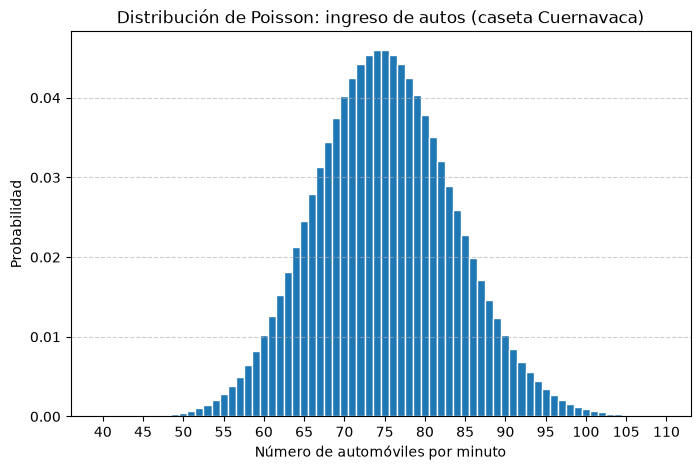

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

lam = 75

x_grafica = np.arange(40, 110)
prob_grafica = poisson.pmf(x_grafica, lam)


plt.figure(figsize=(8, 5))

plt.bar(x_grafica, prob_grafica, width=1, edgecolor="w", color="#1f77b4")

plt.title("Distribución de Poisson: ingreso de autos (caseta Cuernavaca)")
plt.xlabel("Número de automóviles por minuto")
plt.ylabel("Probabilidad")
plt.xticks(np.arange(40, 111, 5))
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

## Análisis del Perfil y Sesgo de la Curva
Al observar el comportamiento de la distribución, se identifica una estructura **esencialmente simétrica y acampanada**. Aunque teóricamente los modelos de Poisson poseen un sesgo a la derecha, la teoría estadística demuestra que cuando el parámetro $\lambda$ es elevado ($\lambda > 15$), la distribución converge hacia la forma de una campana de Gauss (Distribución Normal), haciendo que el sesgo sea prácticamente imperceptible y el pico se concentre en torno al promedio de 75.

## Solución al Inciso a) Probabilidad de registrar 80 automóviles
Evaluamos la función para un valor puntual de $X = 80$, empleando la tasa de ocurrencia establecida:

$$P(X = 80) = \frac{e^{-75} \cdot 75^{80}}{80!}$$

Desglose de las operaciones de alta magnitud:
* Factor exponencial: $e^{-75} \approx 2.675231 \times 10^{-33}$
* Factor de potencia: $75^{80} \approx 2.607415 \times 10^{150}$
* Denominador factorial: $80! \approx 7.156945 \times 10^{118}$

Resolviendo el cociente resultante:
$$P(X = 80) \approx 0.034320$$

**Conclusión:** Existe una probabilidad del **3.43%** de que ingresen exactamente 80 vehículos por la caseta en un minuto cualquiera.

## Solución al Inciso b) Probabilidad de registrar 50 automóviles
Para determinar la probabilidad de que arriben exactamente 50 autos, aplicamos el modelo con $X = 50$:

$$P(X = 50) = \frac{e^{-75} \cdot 75^{50}}{50!}$$

Debido a que el valor evaluado (50) se encuentra muy distante del promedio esperado (75), la densidad de probabilidad en este extremo de la cola izquierda disminuye drásticamente:
$$P(X = 50) \approx 0.000567$$

**Conclusión:** La probabilidad de que se registre el ingreso de exactamente 50 unidades automotrices es de apenas **0.06%**, lo que clasifica a este escenario como un evento sumamente atípico.

## Solución al Inciso c) Análisis probabilístico para un periodo extendido de 15 minutos
Cuando el marco temporal del experimento se modifica, es matemáticamente obligatorio ajustar la tasa promedio de manera proporcional al nuevo intervalo ($t = 15 \text{ min}$).

Modificación del parámetro:
$$\lambda_{ajustado} = 75 \text{ autos/min} \times 15 \text{ min} = 1125 \text{ autos}$$

Con este nuevo promedio, procedemos a calcular la probabilidad para un éxito de $X = 800$:
$$P(X = 800) = \frac{e^{-1125} \cdot 1125^{800}}{800!}$$

Al procesar la operación, el valor resultante es infinitesimalmente pequeño, por lo que se expresa de la siguiente manera:
$$P(X = 800) \approx 0.000000$$

**Conclusión:** La probabilidad de que ingresen exactamente 800 autos en 15 minutos es prácticamente del **0.00%**. Esto se debe a que el valor de 800 está excesivamente por debajo del volumen esperado para ese tiempo, que es de 1125 vehículos.

## d) Minuta y Conclusiones de la Mesa Redonda: Estrategias de Reactivación Turística Nacional

Tras analizar la coyuntura actual del turismo y el impacto derivado de los desafíos de seguridad pública en el país, el grupo de trabajo estructuró las siguientes propuestas y visiones estratégicas:

1. **Modernización de la Seguridad en Infraestructura Vial:** Sugerimos la implementación urgente de sistemas de monitoreo inteligente (arcos carreteros de reconocimiento facial y de matrículas) interconectados en tiempo real con los centros de comando (C5). Blindar los accesos y autopistas clave es el primer paso indispensable para recuperar la confianza del viajero nacional e internacional.

2. **Apuesta por la Digitalización Integral del Destino:**
Para que México compita por el primer lugar del turismo mundial, proponemos la eliminación de cuellos de botella burocráticos mediante el despliegue de visados electrónicos instantáneos y quioscos migratorios automatizados en todos los aeropuertos internacionales. Un destino de clase mundial debe ofrecer una experiencia ágil desde el momento del aterrizaje.

3. **Sostenibilidad y Descentralización de la Oferta:**
La clave para capturar mercados europeos y asiáticos de alto poder adquisitivo radica en diversificar la oferta más allá del modelo de sol y playa. Proponemos incentivos fiscales para el desarrollo de proyectos de ecoturismo comunitario y turismo arqueológico premium gestionados por poblaciones originarias, garantizando la preservación biocultural y un reparto equitativo de los ingresos.